In [1]:
from __future__ import division, print_function, unicode_literals
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Gradient Descent với hàm 1 biến

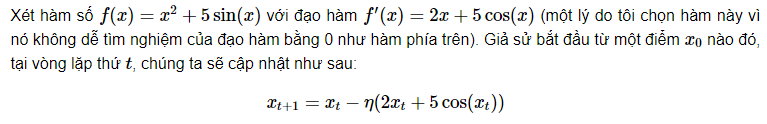

In [2]:
#Tính đạo hàm
def grad1(x):
    return 2 * x + 5 * np.cos(x)

#Tính gtri hàm số
#Ko sử dụng trong thuật toán nhưng đc dùng để ktra tính đạo hàm đúng ko hoặc xem gtri hàm số có giảm theo mỗi vòng lặp hay ko
def cost1(x):
    return x ** 2 + 5 * np.sin(x)

#Phần chính để thực hiện thuật toán GD, đầu vào là learning rate và điểm bắt đầu(dừng lại khi đạo hàm có độ lớn đủ nhỏ)
def myGD1(eta, x0):
    x = [x0]
    for it in range(100):
        x_new = x[-1] - eta * grad1(x[-1])
        if abs(grad1(x_new)) < 1e-3:
            break
        x.append(x_new)
    return (x, it)

### Điểm khởi tạo khác nhau
    Thử tìm nghiệm với các điểm khởi tạo khác nhau là


In [3]:
(x1, it1) = myGD1(0.1, -5)
(x2, it2) = myGD1(0.1, 5)

print("Solution x1 = %f, cost = %f, obtained after %d iterations" % (x1[-1], cost1(x1[-1]), it1))
print("Solution x2 = %f, cost = %f, obtained after %d iterations" % (x2[-1], cost1(x2[-1]), it2))

Solution x1 = -1.110667, cost = -3.246394, obtained after 11 iterations
Solution x2 = -1.110341, cost = -3.246394, obtained after 29 iterations


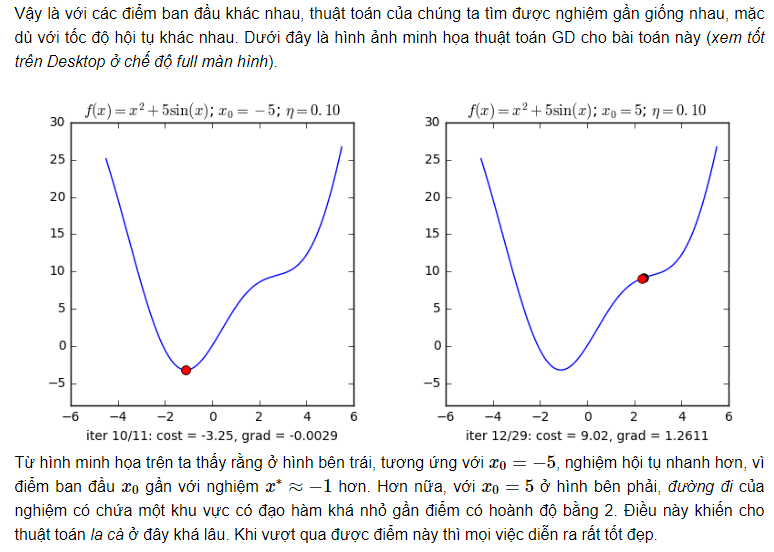

### Learning rate khác nhau
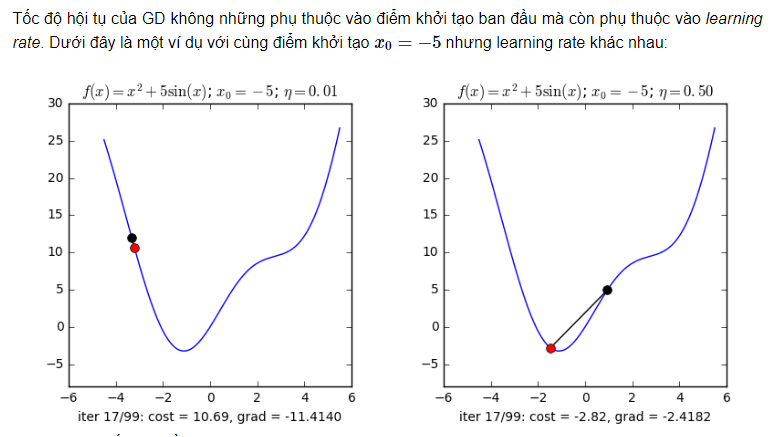

#### Quan sát thấy 2 điều:
    - Vs learning rate nhỏ η = 0.01, tốc độ hội tụ rất chậm. Vd này tôi chọn tối đa 100 vòng lặp nên thuật toán dừng lại trc khi tới đích, mặc dù đã rất gần. Trong thực tế, khi việc tính toán trở nên phức tạp, learning rate quá thấp sẽ ảnh hưởng tới tốc độ của thuật toán rất nhiều, thậm chí không bao giờ tới được đích
    - Vs learning rate lớn η = 0.5, thuật toán tiến rất nhanh tới gần đích sau vài vòng lặp. Tuy nhiên, thuật toán ko hội tụ đc vì bước nhảy quá lớn, khiến nó cứ quẩn quanh ở đích
#### Việc chọn learning rate rất quan trọng trong các bài toán thực tế. Việc lựa chọn gtri này phụ thuộc nhiều vào từng bài toán và phải làm một vài thí nghiệm để chọn ra gtri tốt nhất. Ngoài ra, tùy vào 1 số bài toán, GD có thể làm việc hiệu quả hơn bằng cách chọn ra learning rate phù hợp hoặc chọn learning rate khác nhau ở mỗi vòng lặp

# Gradient Descent với hàm nhiều biến

In [4]:
np.random.seed(2)

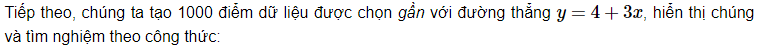

Solution found by formula: w = [[4.0071715  2.98225924]]


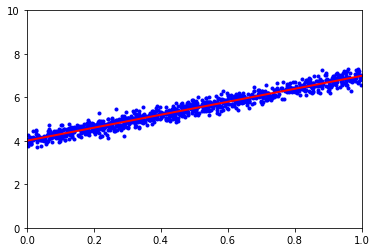

In [5]:
X = np.random.rand(1000, 1)
y = 4 + 3 * X + 0.2 * np.random.randn(1000, 1) #Noise added

#Building Xbar
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w_lr = np.dot(np.linalg.pinv(A), b)
print("Solution found by formula: w =", w_lr.T)

#Display result
w = w_lr
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(0, 1, 2, endpoint = True)
y0 = w_0 + w_1 * x0

#Draw the fitting line
plt.plot(X.T, y.T, "b.") #data
plt.plot(x0, y0, "r", linewidth = 2) #the fitting line
plt.axis([0, 1, 0, 10])
plt.show()

#### Đường thẳng tìm đc là đường màu đỏ có phương trình y ≈ 4 + 2.998x

In [6]:
#Đạo hàm
def grad(w):
    N = Xbar.shape[0]
    return 1 / N * Xbar.T.dot(Xbar.dot(w) - y)

#Hàm mất mát
def cost(w):
    N = Xbar.shape[0]
    return 0.5 / N * np.linalg.norm(y - Xbar.dot(w), 2) ** 2

### Kiểm tra đạo hàm và có thể áp dụng vs 1 hàm số(của 1 vector) bất kỳ vs cost và grad tính phía trên

In [11]:
def numerical_grad(w, cost):
    eps = 1e-6
    g = np.zeros_like(w)
    for i in range(len(w)):
        w_p = w.copy()
        w_n = w.copy()
        w_p[i] += eps 
        w_n[i] -= eps
        g[i] = (cost(w_p) - cost(w_n)) / (2 * eps)
    return g

def check_grad(w, cost, grad):
    w = np.random.rand(w.shape[0], w.shape[1])
    grad1 = grad(w)
    grad2 = numerical_grad(w, cost)
    return True if np.linalg.norm(grad1 - grad2) < 1e-6 else False

print("Checking gradient...", check_grad(np.random.rand(2, 1), cost, grad))

Checking gradient... True


#### Sau khi có đc đạo hàm khá chính xác, ta viết hàm cho GD

In [8]:
def myGD(w_init, grad, eta):
    w = [w_init]
    for it in range(100):
        w_new = w[-1] - eta * grad(w[-1])
        if np.linalg.norm(grad(w_new))/len(w_new) < 1e-3:
            break
        w.append(w_new)
    return (w, it)

w_init = np.array([[2], [1]])
(w1, it1) = myGD(w_init, grad, 1)
print("Solution found by GD: w =", w1[-1].T, ",\nafter %d iterations" % (it1 + 1))

Solution found by GD: w = [[4.02199496 2.95380036]] ,
after 50 iterations


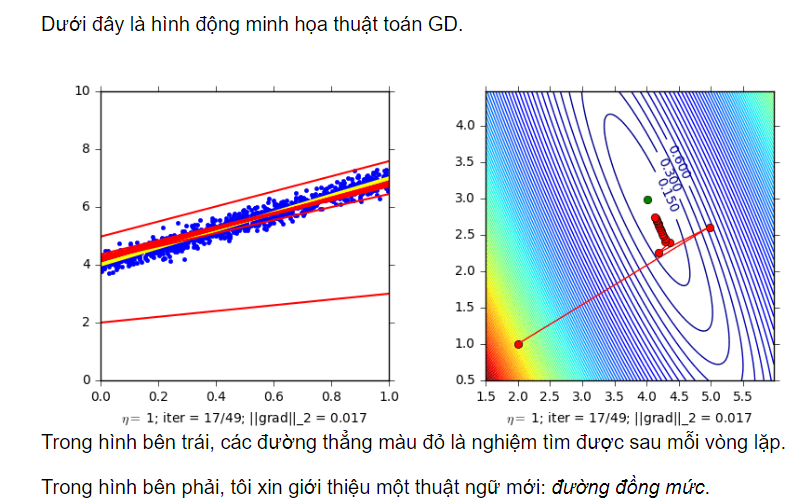